In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error,mean_absolute_percentage_error
import math

In [ ]:
df_copy.travel_day_of_month.value_counts()

,count
travel_day_of_month,
3,5881
2,5645
12,5504
4,3810
13,2332
1,2216
14,2184
19,1999
18,1978


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile

with zipfile.ZipFile("/content/transport_csv.zip", 'r') as zip_ref:
    zip_ref.extract("Data_Science_Capstone_Project_Nairobi _Transport_Data/train_revised.csv", "/content/")

df = pd.read_csv("/content/Data_Science_Capstone_Project_Nairobi _Transport_Data/train_revised.csv")
display(df.head())

,ride_id,seat_number,payment_method,payment_receipt,travel_date,travel_time,travel_from,travel_to,car_type,max_capacity
0,1442,15A,Mpesa,UZUEHCBUSO,17-10-17,7:15,Migori,Nairobi,Bus,49
1,5437,14A,Mpesa,TIHLBUSGTE,19-11-17,7:12,Migori,Nairobi,Bus,49
2,5710,8B,Mpesa,EQX8Q5G19O,26-11-17,7:05,Keroka,Nairobi,Bus,49
3,5777,19A,Mpesa,SGP18CL0ME,27-11-17,7:10,Homa Bay,Nairobi,Bus,49
4,5778,11A,Mpesa,BM97HFRGL9,27-11-17,7:12,Migori,Nairobi,Bus,49


In [ ]:
df.head()


,ride_id,seat_number,payment_method,payment_receipt,travel_date,travel_time,travel_from,travel_to,car_type,max_capacity
0,1442,15A,Mpesa,UZUEHCBUSO,17-10-17,7:15,Migori,Nairobi,Bus,49
1,5437,14A,Mpesa,TIHLBUSGTE,19-11-17,7:12,Migori,Nairobi,Bus,49
2,5710,8B,Mpesa,EQX8Q5G19O,26-11-17,7:05,Keroka,Nairobi,Bus,49
3,5777,19A,Mpesa,SGP18CL0ME,27-11-17,7:10,Homa Bay,Nairobi,Bus,49
4,5778,11A,Mpesa,BM97HFRGL9,27-11-17,7:12,Migori,Nairobi,Bus,49


In [ ]:
df.shape

(51645, 10)

In [ ]:
df.info

<bound method DataFrame.info of        ride_id seat_number payment_method payment_receipt travel_date  \
0         1442         15A          Mpesa      UZUEHCBUSO    17-10-17   
1         5437         14A          Mpesa      TIHLBUSGTE    19-11-17   
2         5710          8B          Mpesa      EQX8Q5G19O    26-11-17   
3         5777         19A          Mpesa      SGP18CL0ME    27-11-17   
4         5778         11A          Mpesa      BM97HFRGL9    27-11-17   
...        ...         ...            ...             ...         ...   
51640    13826          9B          Mpesa      8V2XDDZR6V    20-04-18   
51641    13809         18A          Mpesa      4PEBSVJSNK    20-04-18   
51642    13809         17A          Mpesa      LVN64LZDNN    20-04-18   
51643    13796         16B          Mpesa      REYBSKTYWN    20-04-18   
51644    14304           7          Mpesa      AQN7FBUSGP    14-11-17   

      travel_time travel_from travel_to car_type  max_capacity  
0            7:15      Migori   Nairobi      Bus            49  
1            7:12      Migori   Nairobi      Bus            49  
2            7:05      Keroka   Nairobi      Bus            49  
3            7:10    Homa Bay   Nairobi      Bus            49  
4            7:12      Migori   Nairobi      Bus            49  
...           ...         ...       ...      ...           ...  
51640        8:00      Awendo   Nairobi      Bus            49  
51641        8:00      Migori   Nairobi      Bus            49  
51642        8:00      Migori   Nairobi      Bus            49  
51643        7:08      Awendo   Nairobi      Bus            49  
51644        5:10       Kisii   Nairobi      Bus            49  

[51645 rows x 10 columns]>

In [ ]:
df.duplicated().value_counts()

,count
False,51645


In [ ]:
df.isnull().sum()

,0
ride_id,0
seat_number,0
payment_method,0
payment_receipt,0
travel_date,0
travel_time,0
travel_from,0
travel_to,0
car_type,0
max_capacity,0


In [ ]:
df.columns

Index(['ride_id', 'seat_number', 'payment_method', 'payment_receipt',
       'travel_date', 'travel_time', 'travel_from', 'travel_to', 'car_type',
       'max_capacity'],
      dtype='object')

In [ ]:
df.describe(include='object')

,seat_number,payment_method,payment_receipt,travel_date,travel_time,travel_from,travel_to,car_type
count,51645,51645,51645,51645,51645,51645,51645,51645
unique,61,2,51645,149,78,17,1,2
top,1,Mpesa,AQN7FBUSGP,10-12-17,7:09,Kisii,Nairobi,Bus
freq,2065,51532,1,856,3926,22607,51645,31985


In [ ]:
df.describe(include='object').iloc[1, :]

,unique
seat_number,61
payment_method,2
payment_receipt,51645
travel_date,149
travel_time,78
travel_from,17
travel_to,1
car_type,2


In [ ]:
len(df['ride_id'].unique())

6249

In [ ]:
temp_df = df.groupby('ride_id')['seat_number'].count().reset_index()
temp_df.rename(columns = {'seat_number':'number_of_ticket'},inplace=True)
temp_df.head()

,ride_id,number_of_ticket
0,1442,1
1,5437,1
2,5710,1
3,5777,5
4,5778,31


In [ ]:
df = df.merge(temp_df,how = 'left', on = 'ride_id')
df.head()

,ride_id,seat_number,payment_method,payment_receipt,travel_date,travel_time,travel_from,travel_to,car_type,max_capacity,number_of_ticket
0,1442,15A,Mpesa,UZUEHCBUSO,17-10-17,7:15,Migori,Nairobi,Bus,49,1
1,5437,14A,Mpesa,TIHLBUSGTE,19-11-17,7:12,Migori,Nairobi,Bus,49,1
2,5710,8B,Mpesa,EQX8Q5G19O,26-11-17,7:05,Keroka,Nairobi,Bus,49,1
3,5777,19A,Mpesa,SGP18CL0ME,27-11-17,7:10,Homa Bay,Nairobi,Bus,49,5
4,5778,11A,Mpesa,BM97HFRGL9,27-11-17,7:12,Migori,Nairobi,Bus,49,31


In [ ]:
df['date_time'] = pd.to_datetime(df['travel_date']+' '+df['travel_time'])
df['travel_date'] = pd.to_datetime(df['travel_date'])

/tmp/ipython-input-3267580240.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_time'] = pd.to_datetime(df['travel_date']+' '+df['travel_time'])
/tmp/ipython-input-3267580240.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['travel_date'] = pd.to_datetime(df['travel_date'])


In [ ]:
df_copy = df.copy()

In [ ]:
def create_date_cols(df_temp):
  df_temp['travel_month'] = df_temp['travel_date'].dt.month
  df_temp['travel_year'] = df_temp['travel_date'].dt.year
  df_temp['travel_day_of_month'] = df_temp['travel_date'].dt.day
  df_temp['travel_day_of_year'] = df_temp['travel_date'].dt.dayofyear
  df_temp['travel_day_of_week'] = df_temp['travel_date'].dt.dayofweek
  df_temp['travel_hour'] = pd.to_datetime(df_temp['travel_time']).dt.hour
  df_temp['quarter'] = df_temp['travel_date'].dt.quarter
  df_temp['is_weekend'] = df_temp['travel_day_of_week'].apply(lambda x: 1 if x in [5,6] else 0)

  return df_temp

df_copy = create_date_cols(df_copy)

/tmp/ipython-input-3701921142.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_temp['travel_hour'] = pd.to_datetime(df_temp['travel_time']).dt.hour


In [ ]:
df_copy.columns

Index(['ride_id', 'seat_number', 'payment_method', 'payment_receipt',
       'travel_date', 'travel_time', 'travel_from', 'travel_to', 'car_type',
       'max_capacity', 'number_of_ticket', 'date_time', 'travel_month',
       'travel_year', 'travel_day_of_month', 'travel_day_of_year',
       'travel_day_of_week', 'travel_hour', 'quarter', 'is_weekend'],
      dtype='object')

In [ ]:
df_copy.head()

,ride_id,seat_number,payment_method,payment_receipt,travel_date,travel_time,travel_from,travel_to,car_type,max_capacity,number_of_ticket,date_time,travel_month,travel_year,travel_day_of_month,travel_day_of_year,travel_day_of_week,travel_hour,quarter,is_weekend
0,1442,15A,Mpesa,UZUEHCBUSO,2017-10-17,7:15,Migori,Nairobi,Bus,49,1,2017-10-17 07:15:00,10,2017,17,290,1,7,4,0
1,5437,14A,Mpesa,TIHLBUSGTE,2017-11-19,7:12,Migori,Nairobi,Bus,49,1,2017-11-19 07:12:00,11,2017,19,323,6,7,4,1
2,5710,8B,Mpesa,EQX8Q5G19O,2017-11-26,7:05,Keroka,Nairobi,Bus,49,1,2017-11-26 07:05:00,11,2017,26,330,6,7,4,1
3,5777,19A,Mpesa,SGP18CL0ME,2017-11-27,7:10,Homa Bay,Nairobi,Bus,49,5,2017-11-27 07:10:00,11,2017,27,331,0,7,4,0
4,5778,11A,Mpesa,BM97HFRGL9,2017-11-27,7:12,Migori,Nairobi,Bus,49,31,2017-11-27 07:12:00,11,2017,27,331,0,7,4,0


In [ ]:
df_copy['travel_time'] = df_copy['travel_time'].str.split(':').apply(lambda x: round(int(x[0]) + int(x[1])/60 ,2) )


In [ ]:
def get_period(hour):
  if hour<7: return 'em'
  elif hour>=7 and hour<=11: return 'mor'
  elif hour>11 and hour<=15: return 'an'
  elif hour>15 and hour<=19: return 'evn'
  elif hour>19 and hour<=24: return 'nght'

df_copy['time_period_of_day'] = df_copy['travel_hour'].apply(get_period)


In [ ]:
import warnings
warnings.filterwarnings('ignore')

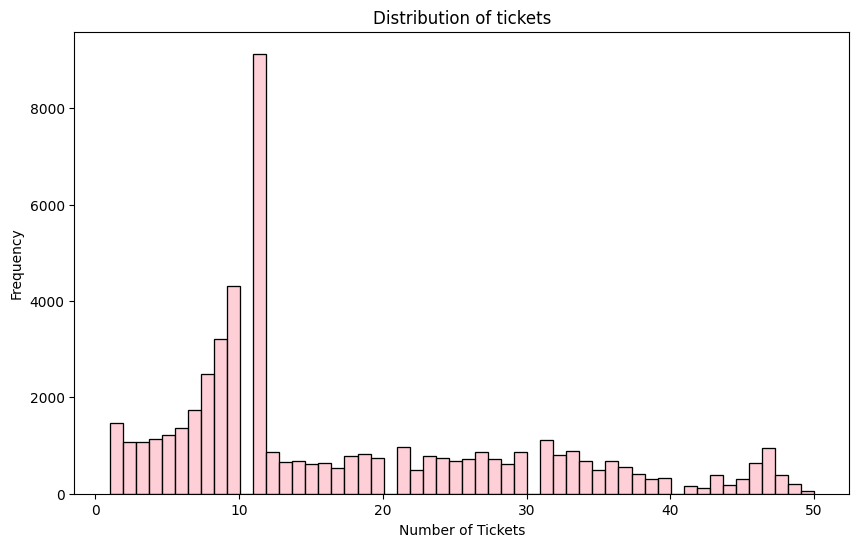

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df_copy['number_of_ticket'], color='pink')
plt.title("Distribution of tickets")
plt.xlabel("Number of Tickets")
plt.ylabel("Frequency")
plt.show()

Text(0, 0.5, 'Count')

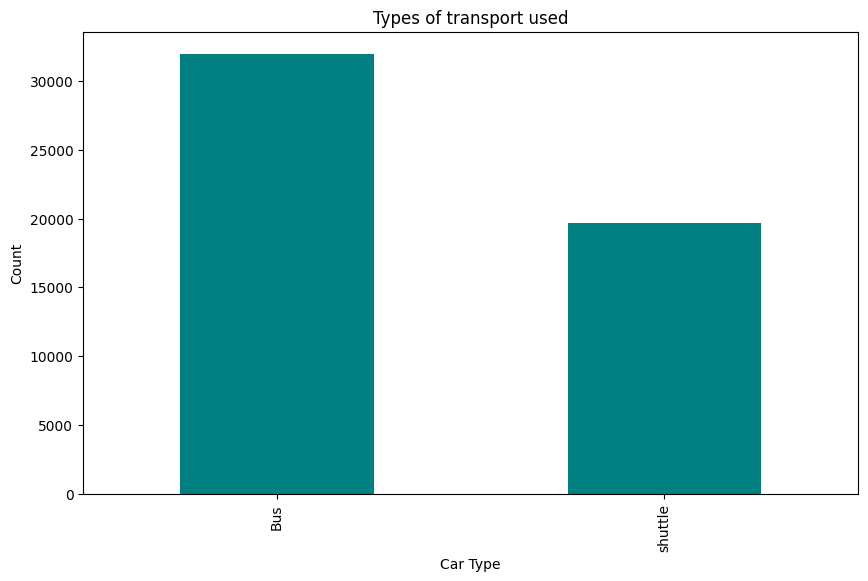

In [ ]:
plt.figure(figsize=(10,6))
df_copy['car_type'].value_counts().plot(kind='bar',color='teal')
plt.title("Types of transport used")
plt.xlabel('Car Type')
plt.ylabel('Count')


Text(0, 0.5, 'Number of Tickets')

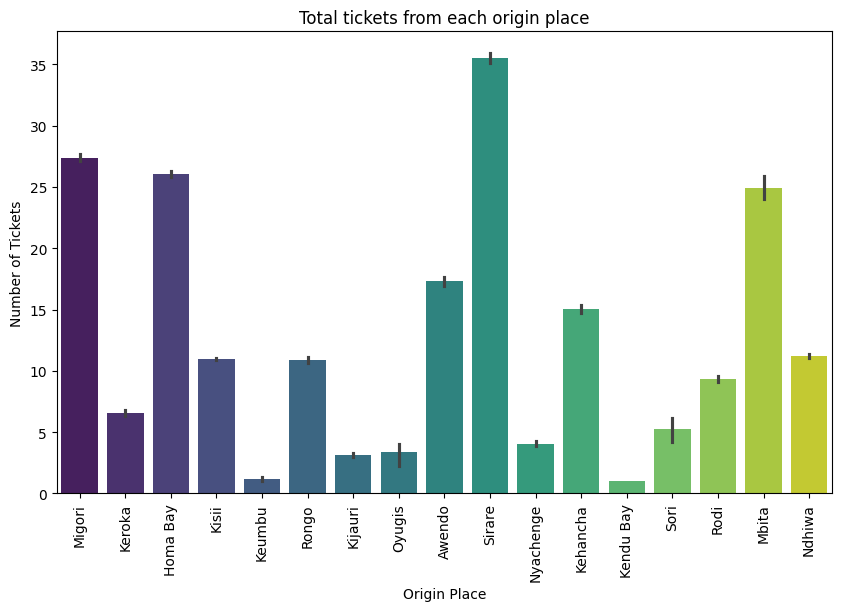

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=df_copy,x='travel_from',y='number_of_ticket', palette='viridis')
plt.xticks(rotation=90)
plt.title('Total tickets from each origin place')
plt.xlabel('Origin Place')
plt.ylabel('Number of Tickets')

Text(0, 0.5, 'Count')

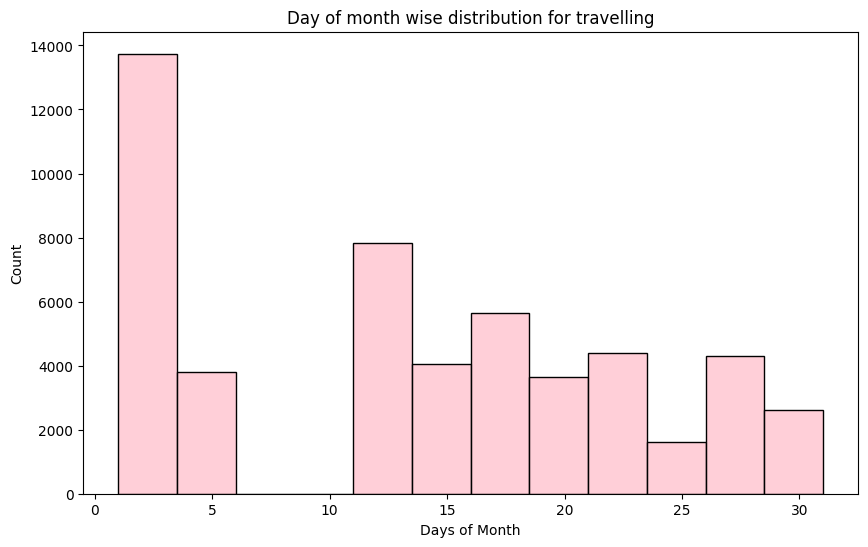

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df_copy['travel_day_of_month'],bins=12, color='pink')
plt.title('Day of month wise distribution for travelling')
plt.xlabel('Days of Month')
plt.ylabel('Count')

Text(0.5, 1.0, 'Number of tickets for every day of month')

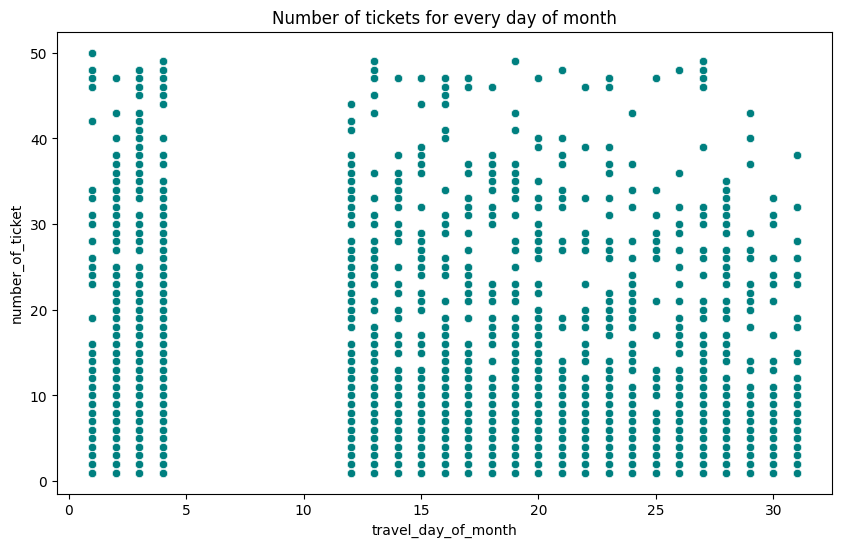

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_copy, x='travel_day_of_month',y='number_of_ticket',color='teal')
plt.title('Number of tickets for every day of month')

In [ ]:
df_copy.travel_month.value_counts()

,count
travel_month,
12,9516
2,8211
1,7278
3,6097
4,5086
11,3089
9,2225
8,2210
7,2150


In [ ]:
df_copy.travel_day_of_year.value_counts()


,count
travel_day_of_year,
285,856
348,797
347,730
193,723
224,722
...,...
359,8
330,1
290,1


In [ ]:
df_copy.time_period_of_day.value_counts()

,count
time_period_of_day,
mor,42831
evn,4369
em,3953
nght,492


In [ ]:
distance_from_nairobi = {'Awendo':351, 'Homa Bay':360, 'Kehancha': 387.7, 'Keroka': 280, 'Keumbu':295, 'Kijauri':271,
                         'Kisii':305.1, 'Mbita':401, 'Migori': 370, 'Ndhiwa': 371, 'Nyachenge':326, 'Rodi':348, 'Rongo':332,
                         'Sirare':392, 'Sori':399}
df_copy['distance_to_destination'] = df_copy['travel_from'].map(distance_from_nairobi)

In [ ]:
df_copy.columns

Index(['ride_id', 'seat_number', 'payment_method', 'payment_receipt',
       'travel_date', 'travel_time', 'travel_from', 'travel_to', 'car_type',
       'max_capacity', 'number_of_ticket', 'date_time', 'travel_month',
       'travel_year', 'travel_day_of_month', 'travel_day_of_year',
       'travel_day_of_week', 'travel_hour', 'quarter', 'is_weekend',
       'time_period_of_day', 'distance_to_destination'],
      dtype='object')

In [ ]:
df_copy.isnull().sum()

,0
ride_id,0
seat_number,0
payment_method,0
payment_receipt,0
travel_date,0
travel_time,0
travel_from,0
travel_to,0
car_type,0
max_capacity,0


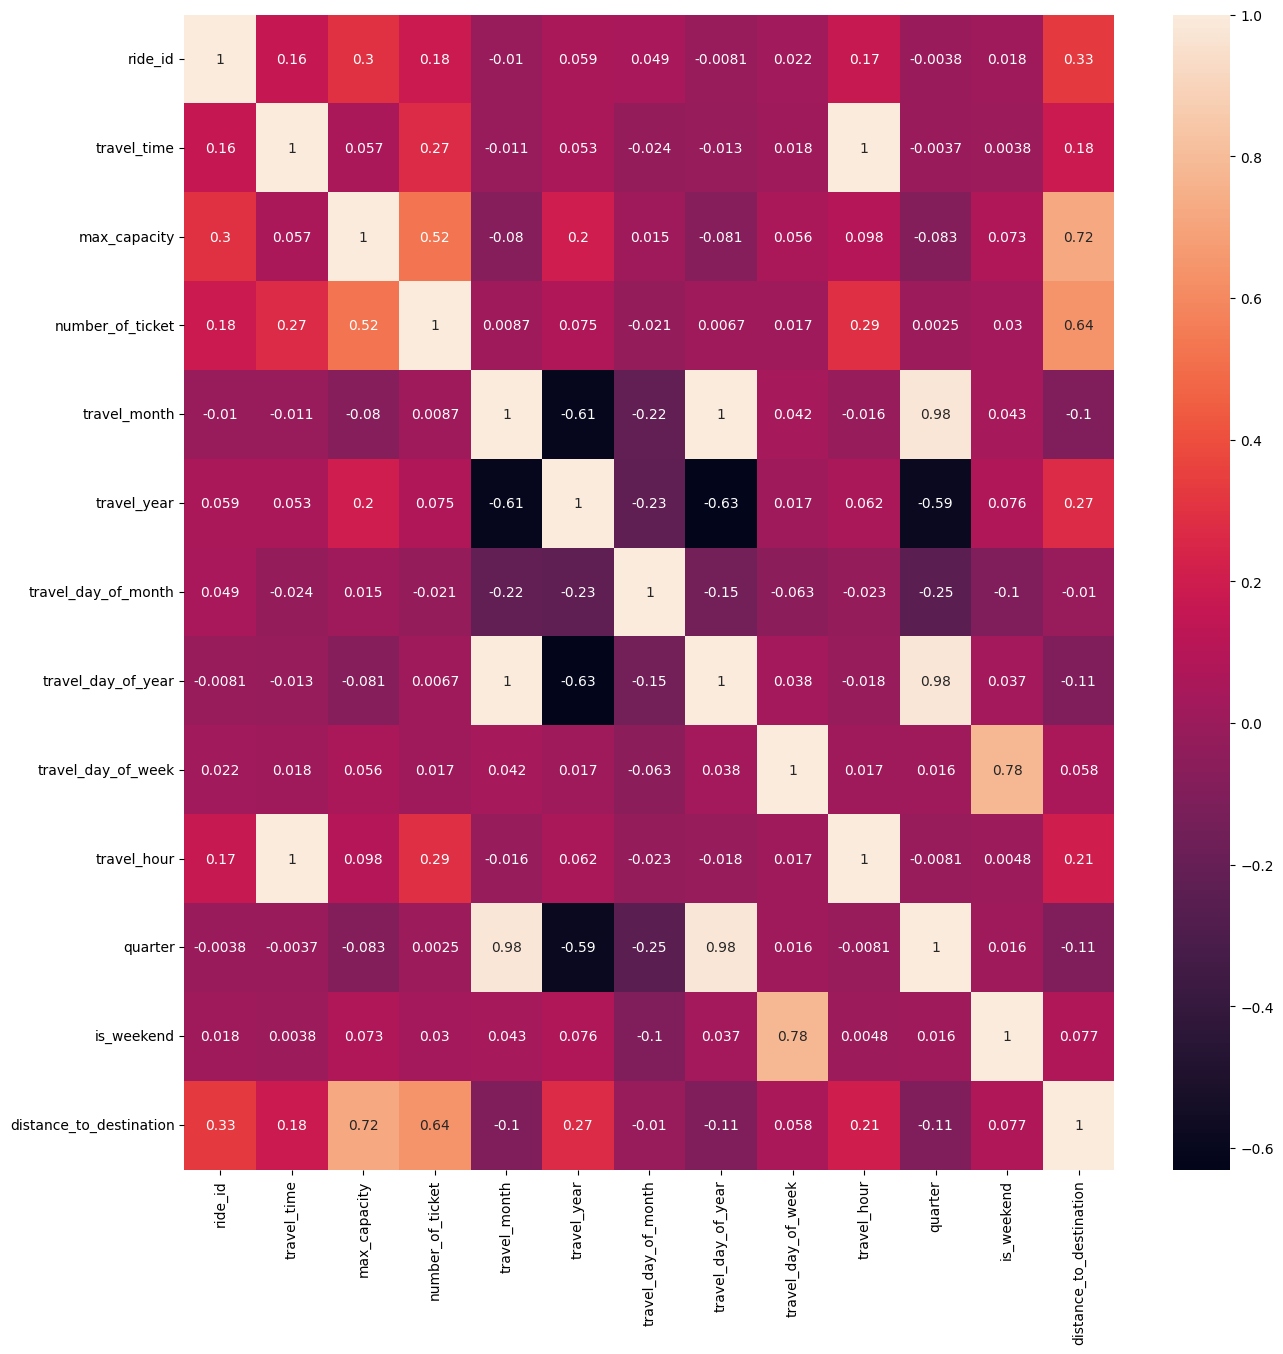

In [ ]:
plt.figure(figsize=(15,15))
sns.heatmap(df_copy.select_dtypes(include=np.number).corr(),annot=True)
plt.show()

In [ ]:
from sklearn import preprocessing
final_df = pd.get_dummies(df_copy, columns = ['travel_from'])


#Label encoding car_type column
label_encoder = {'Bus':1,'shuttle':0}
final_df.replace(label_encoder, inplace=True)
final_df.head()

,ride_id,seat_number,payment_method,payment_receipt,travel_date,travel_time,travel_to,car_type,max_capacity,number_of_ticket,...,travel_from_Kisii,travel_from_Mbita,travel_from_Migori,travel_from_Ndhiwa,travel_from_Nyachenge,travel_from_Oyugis,travel_from_Rodi,travel_from_Rongo,travel_from_Sirare,travel_from_Sori
0,1442,15A,Mpesa,UZUEHCBUSO,2017-10-17,7.25,Nairobi,1,49,1,...,False,False,True,False,False,False,False,False,False,False
1,5437,14A,Mpesa,TIHLBUSGTE,2017-11-19,7.20,Nairobi,1,49,1,...,False,False,True,False,False,False,False,False,False,False
2,5710,8B,Mpesa,EQX8Q5G19O,2017-11-26,7.08,Nairobi,1,49,1,...,False,False,False,False,False,False,False,False,False,False
3,5777,19A,Mpesa,SGP18CL0ME,2017-11-27,7.17,Nairobi,1,49,5,...,False,False,False,False,False,False,False,False,False,False
4,5778,11A,Mpesa,BM97HFRGL9,2017-11-27,7.20,Nairobi,1,49,31,...,False,False,True,False,False,False,False,False,False,False


In [ ]:

#Importing required libraries
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error,mean_absolute_percentage_error
import math

In [ ]:

def evaluate_metric(actual,predicted):
  print('MSE is {}'.format(mean_squared_error(actual, predicted)))
  print('RMSE is {}'.format(math.sqrt(mean_squared_error(actual, predicted))))
  print('MAE is {}'.format(mean_absolute_error(actual, predicted)))
  print('MAPE is {}'.format(np.mean(np.abs((actual - predicted) / actual)) * 100))
  print('R2 Score is {}'.format(r2_score(actual, predicted)))

In [ ]:
df_copy.head()

,ride_id,seat_number,payment_method,payment_receipt,travel_date,travel_time,travel_from,travel_to,car_type,max_capacity,...,travel_month,travel_year,travel_day_of_month,travel_day_of_year,travel_day_of_week,travel_hour,quarter,is_weekend,time_period_of_day,distance_to_destination
0,1442,15A,Mpesa,UZUEHCBUSO,2017-10-17,7.25,Migori,Nairobi,Bus,49,...,10,2017,17,290,1,7,4,0,mor,370.0
1,5437,14A,Mpesa,TIHLBUSGTE,2017-11-19,7.20,Migori,Nairobi,Bus,49,...,11,2017,19,323,6,7,4,1,mor,370.0
2,5710,8B,Mpesa,EQX8Q5G19O,2017-11-26,7.08,Keroka,Nairobi,Bus,49,...,11,2017,26,330,6,7,4,1,mor,280.0
3,5777,19A,Mpesa,SGP18CL0ME,2017-11-27,7.17,Homa Bay,Nairobi,Bus,49,...,11,2017,27,331,0,7,4,0,mor,360.0
4,5778,11A,Mpesa,BM97HFRGL9,2017-11-27,7.20,Migori,Nairobi,Bus,49,...,11,2017,27,331,0,7,4,0,mor,370.0


In [ ]:

df_copy.travel_month.value_counts()

,count
travel_month,
12,9516
2,8211
1,7278
3,6097
4,5086
11,3089
9,2225
8,2210
7,2150


In [ ]:
df_copy.travel_day_of_year.value_counts()


,count
travel_day_of_year,
285,856
348,797
347,730
193,723
224,722
...,...
359,8
330,1
290,1


In [ ]:
df_copy.travel_day_of_month.value_counts()

,count
travel_day_of_month,
3,5881
2,5645
12,5504
4,3810
13,2332
1,2216
14,2184
19,1999
18,1978


In [ ]:
df_copy.time_period_of_day.value_counts()


,count
time_period_of_day,
mor,42831
evn,4369
em,3953
nght,492


In [ ]:
period_dict = dict(df_copy.time_period_of_day.value_counts())
df_copy['travel_hour_wise_weights'] = np.log1p(df_copy.time_period_of_day.map(period_dict))

# Creating a seperate column for giving day of a year wise weights for the hours column
day_of_year_dict = dict(df_copy.travel_day_of_year.value_counts())
df_copy['travel_day_of_year_wise_weights'] = np.log1p(df_copy.travel_day_of_year.map(day_of_year_dict))

# Giving weights to the each days of the month based on the frequency of ticket bookings
day_of_month_wise_weights_dict = {2:1, 12:1, 3:1, 4:2, 1:3, 13:3, 14:3, 16:3, 28:3, 19:3, 18:3, 15:3, 17:3, 20:3, 22:4, 21:4, 27:4, 29:4, 23:4, 24:4, 26:4, 30:4, 25:4, 31:4}
df_copy['travel_day_of_month_wise_weights'] = df_copy.travel_day_of_month.replace(day_of_month_wise_weights_dict)

# Creating a column for giving weights to the each months of a year based on the frequency of ticket bookings
travel_month_wise_weights_dict = {12: 1,
 2: 1,
 1: 1,
 3: 1,
 4: 1,
 11: 2,
 9: 3,
 7: 3,
 8: 3,
 10: 3,
 6: 3,
 5: 3}
df_copy['travel_month_wise_weights'] = df_copy.travel_month.replace(travel_month_wise_weights_dict)

df_copy.head(3)


,ride_id,seat_number,payment_method,payment_receipt,travel_date,travel_time,travel_from,travel_to,car_type,max_capacity,...,travel_day_of_week,travel_hour,quarter,is_weekend,time_period_of_day,distance_to_destination,travel_hour_wise_weights,travel_day_of_year_wise_weights,travel_day_of_month_wise_weights,travel_month_wise_weights
0,1442,15A,Mpesa,UZUEHCBUSO,2017-10-17,7.25,Migori,Nairobi,Bus,49,...,1,7,4,0,mor,370.0,10.665041,0.693147,3,3
1,5437,14A,Mpesa,TIHLBUSGTE,2017-11-19,7.20,Migori,Nairobi,Bus,49,...,6,7,4,1,mor,370.0,10.665041,0.693147,3,2
2,5710,8B,Mpesa,EQX8Q5G19O,2017-11-26,7.08,Keroka,Nairobi,Bus,49,...,6,7,4,1,mor,280.0,10.665041,0.693147,4,2


In [ ]:


# Creating a method to create new features in df

# Creating columns for time difference between next and previous buses for each of the origin places (travel_from).
def find_difference_bw_bus(data):

  data.sort_values(["travel_from","date_time"],inplace=True,ascending=True)
  data["Time_gap_btw_0_1_next_bus"]=(data["date_time"]-data.groupby(["travel_from"]).date_time.shift(-1)).dt.total_seconds()/3600
  data["Time_gap_btw_0_1_previous_bus"]=(data["date_time"]-data.groupby(["travel_from"]).date_time.shift(1)).dt.total_seconds()/3600
  data["Time_gap_btw_0_2_next_bus"]=(data["date_time"]-data.groupby(["travel_from"]).date_time.shift(-2)).dt.total_seconds()/3600
  data["Time_gap_btw_0_2_previous_bus"]=(data["date_time"]-data.groupby(["travel_from"]).date_time.shift(2)).dt.total_seconds()/3600
  data["Time_gap_btw_0_3_next_bus"]=(data["date_time"]-data.groupby(["travel_from"]).date_time.shift(-3)).dt.total_seconds()/3600
  data["Time_gap_btw_0_3_previous_bus"]=(data["date_time"]-data.groupby(["travel_from"]).date_time.shift(3)).dt.total_seconds()/3600
  data["Time_gap_btw_next_previous_bus"]=(data.groupby(["travel_from"]).date_time.shift(-1)-data.groupby(["travel_from"]).date_time.shift(1)).dt.total_seconds()/3600
  cols=["Time_gap_btw_0_1_next_bus", "Time_gap_btw_0_1_previous_bus", "Time_gap_btw_0_2_next_bus","Time_gap_btw_0_2_previous_bus",
      "Time_gap_btw_0_3_next_bus", "Time_gap_btw_0_3_previous_bus",
      "Time_gap_btw_next_previous_bus"]

  #Handling missing values
  data[cols]=data.groupby(["travel_from"])[cols].fillna(method="ffill")
  data[cols]=data.groupby(["travel_from"])[cols].fillna(method="backfill")


  return data

In [ ]:
transport_data_new = find_difference_bw_bus(df_copy)


transport_data_new.groupby(["travel_from"]).date_time.shift(-1)


,date_time
2152,2017-05-12 07:08:00
2153,2018-01-04 07:08:00
44611,2018-01-04 07:08:00
44637,2018-01-04 07:08:00
44638,2018-01-04 07:08:00
...,...
48412,2018-12-04 07:05:00
48457,2018-12-04 07:05:00
48472,2018-12-04 23:10:00
48114,2018-12-04 23:10:00


In [ ]:

transport_data_new[['travel_from','date_time','Time_gap_btw_0_1_next_bus','Time_gap_btw_0_1_previous_bus']].head()

,travel_from,date_time,Time_gap_btw_0_1_next_bus,Time_gap_btw_0_1_previous_bus
2152,Awendo,2017-05-12 07:08:00,0.0,0.0
2153,Awendo,2017-05-12 07:08:00,-5688.0,0.0
44611,Awendo,2018-01-04 07:08:00,0.0,5688.0
44637,Awendo,2018-01-04 07:08:00,0.0,0.0
44638,Awendo,2018-01-04 07:08:00,0.0,0.0


In [ ]:

distance_from_nairobi = {'Awendo':351, 'Homa Bay':360, 'Kehancha': 387.7, 'Keroka': 280, 'Keumbu':295, 'Kijauri':271,
                         'Kisii':305.1, 'Mbita':401, 'Migori': 370, 'Ndhiwa': 371, 'Nyachenge':326, 'Rodi':348, 'Rongo':332,
                         'Sirare':392, 'Sori':399}

transport_data_new['distance_to_destination'] = transport_data_new['travel_from'].map(distance_from_nairobi)

In [ ]:
transport_data_new.columns

Index(['ride_id', 'seat_number', 'payment_method', 'payment_receipt',
       'travel_date', 'travel_time', 'travel_from', 'travel_to', 'car_type',
       'max_capacity', 'number_of_ticket', 'date_time', 'travel_month',
       'travel_year', 'travel_day_of_month', 'travel_day_of_year',
       'travel_day_of_week', 'travel_hour', 'quarter', 'is_weekend',
       'time_period_of_day', 'distance_to_destination',
       'travel_hour_wise_weights', 'travel_day_of_year_wise_weights',
       'travel_day_of_month_wise_weights', 'travel_month_wise_weights',
       'Time_gap_btw_0_1_next_bus', 'Time_gap_btw_0_1_previous_bus',
       'Time_gap_btw_0_2_next_bus', 'Time_gap_btw_0_2_previous_bus',
       'Time_gap_btw_0_3_next_bus', 'Time_gap_btw_0_3_previous_bus',
       'Time_gap_btw_next_previous_bus'],
      dtype='object')

In [ ]:

# Encode your categorical columns
from sklearn import preprocessing
final_df = pd.get_dummies(df_copy, columns = ['travel_from','travel_day_of_month_wise_weights','travel_month_wise_weights'])

In [ ]:
#Label encoding car_type column
label_encoder = {'Bus':1,'shuttle':0}
final_df.replace(label_encoder, inplace=True)
final_df.head()

,ride_id,seat_number,payment_method,payment_receipt,travel_date,travel_time,travel_to,car_type,max_capacity,number_of_ticket,...,travel_from_Rongo,travel_from_Sirare,travel_from_Sori,travel_day_of_month_wise_weights_1,travel_day_of_month_wise_weights_2,travel_day_of_month_wise_weights_3,travel_day_of_month_wise_weights_4,travel_month_wise_weights_1,travel_month_wise_weights_2,travel_month_wise_weights_3
2152,6654,24B,Mpesa,UMAPNYPBAS,2017-05-12,7.13,Nairobi,1,49,2,...,False,False,False,True,False,False,False,False,False,True
2153,6654,23B,Mpesa,ZKRZ3TNVBH,2017-05-12,7.13,Nairobi,1,49,2,...,False,False,False,True,False,False,False,False,False,True
44611,12926,25,Mpesa,NOXLCPZ2MO,2018-01-04,7.13,Nairobi,1,49,20,...,False,False,False,False,True,False,False,True,False,False
44637,12926,20A,Mpesa,3G7ROL43UW,2018-01-04,7.13,Nairobi,1,49,20,...,False,False,False,False,True,False,False,True,False,False
44638,12926,19A,Mpesa,9KWCLXV07N,2018-01-04,7.13,Nairobi,1,49,20,...,False,False,False,False,True,False,False,True,False,False


In [ ]:
cols_to_drop = ['ride_id','travel_date','travel_time','max_capacity','travel_year','number_of_ticket','time_period_of_day','date_time','travel_month','travel_day_of_month','travel_day_of_year','travel_hour', 'seat_number', 'payment_method', 'payment_receipt', 'travel_to']
X = final_df.drop(cols_to_drop,axis=1)

In [ ]:
y = final_df['number_of_ticket']
# Drop rows with missing values from both X and y
X = X.dropna()
y = y[X.index]
y.shape

(51639,)

In [ ]:
# Split your data to train and test.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


X_train.shape

(41311, 38)

In [ ]:
y_train.shape

(41316,)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error,mean_absolute_percentage_error
import math

In [ ]:

#Creating function for evaluation metrics
def evaluate_metric(actual,predicted):
  print('MSE is {}'.format(mean_squared_error(actual, predicted)))
  print('RMSE is {}'.format(math.sqrt(mean_squared_error(actual, predicted))))
  print('MAE is {}'.format(mean_absolute_error(actual, predicted)))
  print('MAPE is {}'.format(np.mean(np.abs((actual - predicted) / actual)) * 100))
  print('R2 Score is {}'.format(r2_score(actual, predicted)))

In [ ]:
regressor = LinearRegression()

# Fit the Algorithm
regressor.fit(X_train, y_train)
# Predict on the model

y_train_pred = regressor.predict(X_train)

y_test_pred = regressor.predict(X_test)

### Evaluate the Linear Regression model

In [ ]:
print("Metrics for Training data")
evaluate_metric(y_train,y_train_pred)

print("\nMetrics for Test data")
evaluate_metric(y_test,y_test_pred)

Metrics for Training data
MSE is 64.08121984569021
RMSE is 8.005074630863238
MAE is 5.634921461104562
MAPE is 74.00007749782392
R2 Score is 0.5815776964499302

Metrics for Test data
MSE is 65.15966220720735
RMSE is 8.072153504933324
MAE is 5.674136937300057
MAPE is 74.91113308297332
R2 Score is 0.5744899098715972


In [ ]:

# ML Model - 2 Implementation
lasso  = Lasso(alpha=0.1 , max_iter= 3000)

# Fit the Algorithm
lasso.fit(X_train, y_train)

# Predict on the model
y_train_pred = lasso.predict(X_train)

y_test_pred = lasso.predict(X_test)

In [ ]:
evaluate_metric(y_train,y_train_pred)
print("Adjusted R2 : ",1-(1-r2_score((y_train), (y_train_pred)))*((X_train.shape[0]-1)/(X_train.shape[0]-X_train.shape[1]-1)))


MSE is 67.65453745321001
RMSE is 8.225237835662261
MAE is 5.866866726615672
MAPE is 77.50534669432156
R2 Score is 0.5582454972774604
Adjusted R2 :  0.5578387645990475


In [ ]:
ridge = Ridge()

# Fit the Algorithm
ridge.fit(X_train,y_train)

# Predict on the model
y_train_pred = ridge.predict(X_train)

y_test_pred = ridge.predict(X_test)

In [ ]:
evaluate_metric(y_train,y_train_pred)
print("Adjusted R2 : ",1-(1-r2_score((y_train), (y_train_pred)))*((X_train.shape[0]-1)/(X_train.shape[0]-X_train.shape[1]-1)))


MSE is 64.08143044315065
RMSE is 8.00508778484975
MAE is 5.63508841159239
MAPE is 74.00421242007312
R2 Score is 0.581576321340737
Adjusted R2 :  0.581191069843619


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor()

# Fit the Algorithm
rfr.fit(X_train,y_train)

# Predict on the model
y_train_pred = rfr.predict(X_train)

y_test_pred = rfr.predict(X_test)

In [ ]:
evaluate_metric(y_train,y_train_pred)
print("Adjusted R2 : ",1-(1-r2_score((y_train), (y_train_pred)))*((X_train.shape[0]-1)/(X_train.shape[0]-X_train.shape[1]-1)))


MSE is 10.798094862683431
RMSE is 3.286045474834977
MAE is 1.6866617566970432
MAPE is 12.187950357800425
R2 Score is 0.9294931691800489
Adjusted R2 :  0.9294282520553357


In [ ]:
import xgboost as xgb
xgbr = xgb.XGBRegressor()

# Fit the Algorithm
xgbr.fit(X_train,y_train)

# Predict on the model
y_train_pred = xgbr.predict(X_train)

y_test_pred = xgbr.predict(X_test)

In [ ]:
evaluate_metric(y_train,y_train_pred)
print("Adjusted R2 : ",1-(1-r2_score((y_train), (y_train_pred)))*((X_train.shape[0]-1)/(X_train.shape[0]-X_train.shape[1]-1)))


MSE is 16.98149871826172
RMSE is 4.120861404883901
MAE is 2.663559913635254
MAPE is 22.663592133873074
R2 Score is 0.8891182541847229
Adjusted R2 :  0.8890161630250751
